=== Initializing ===
Understanding 
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[us]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12

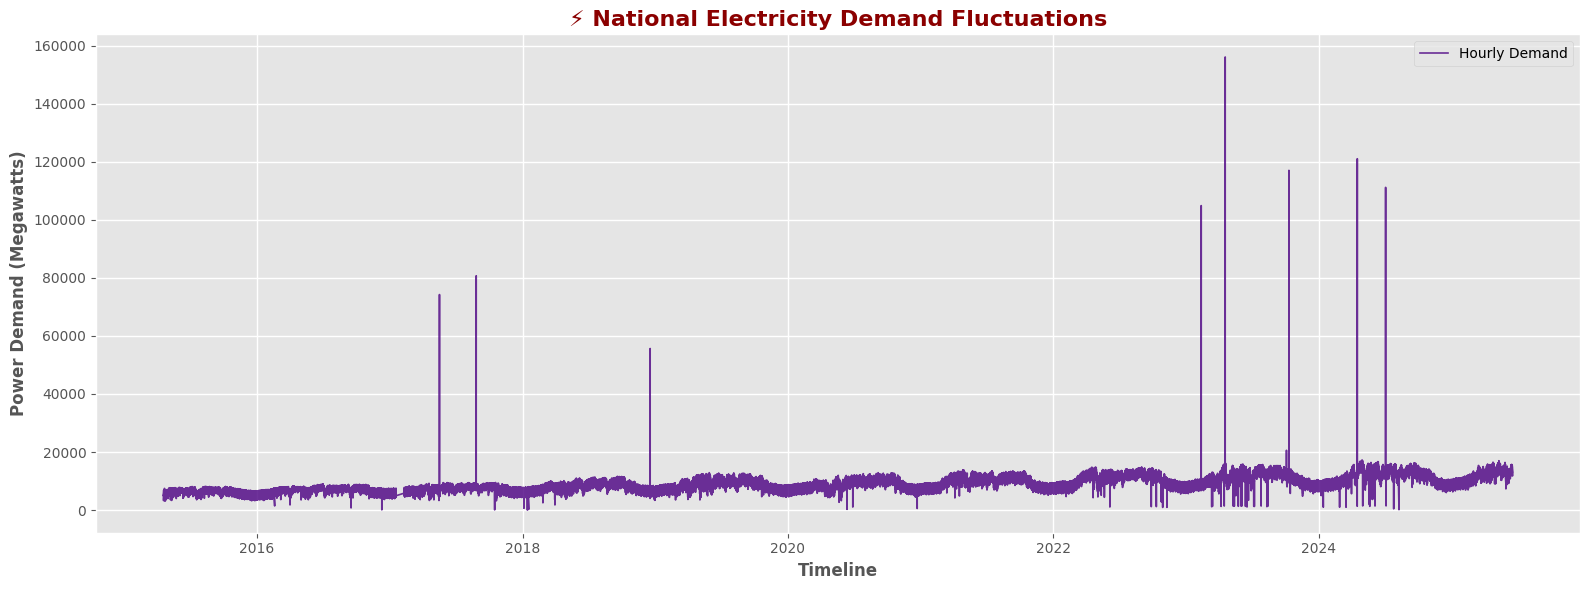


 Demand statistics
--------------------------------------------------
Minimum Demand Recorded: 6.0 MW
Maximum Demand Recorded: 156050.0 MW
Average(mean) Demand: 8819.646044252564 MW
Median Demand: 8422.0 MW


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

print("=== Initializing ===")

power_data = pd.read_excel(r"C:\Users\kavya\OneDrive\Desktop\aiiii\PGCB_date_power_demand.xlsx")
weather_data = pd.read_excel(r"C:\Users\kavya\OneDrive\Desktop\aiiii\weather_data.xlsx")
macro_econ_data = pd.read_csv(r"C:\Users\kavya\OneDrive\Desktop\aiiii\economic_full_1.csv")

print("Understanding ")
print("-" * 50)
print(power_data.info())

print("\n Identifying")
print('-' * 50)
missing_counts  = power_data.isnull().sum()

missing_only =  missing_counts[missing_counts > 0]
if not missing_only.empty:
    print("Columns with missing values:\n", missing_only)
else:
    print("Great! No values found.")

print("\n Visualizing")
print("-" * 50)

plt.style.use('ggplot')
plt.figure(figsize=(16, 6))

plt.plot(power_data['datetime'], power_data['demand_mw'], color='indigo', linewidth=1.2, alpha=0.8, label='Hourly Demand')
plt.title('⚡ National Electricity Demand Fluctuations', fontsize=16, fontweight='bold', color='darkred')
plt.xlabel('Timeline', fontsize=12, fontweight='bold')
plt.ylabel('Power Demand (Megawatts)', fontsize=12, fontweight='bold')
plt.legend()

plt.grid(color='white', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

print("\n Demand statistics")
print("-" * 50)
stats = power_data['demand_mw'].describe()
print(f"Minimum Demand Recorded: {stats['min']} MW")
print(f"Maximum Demand Recorded: {stats['max']} MW")
print(f"Average(mean) Demand: {stats['mean']} MW")
print(f"Median Demand: {stats['50%']} MW")

In [21]:
print("=== Start Data Cleaning ===")

df_power['datetime'] = pd.to_datetime(df_power['datetime'])
df_power.sort_values(by='datetime', ascending=True, inplace=True)

print("\n[Before] Missing values in top columns:")
print(df_power[['demand_mw', 'generation_mw', 'solar', 'wind']].isnull().sum())

df_power.set_index('datetime', inplace=True)

main_cols = ['generation_mw', 'demand_mw', 'gas', 'liquid_fuel', 'coal', 'hydro']
for col in main_cols:
    if col in df_power.columns:
        df_power[col] = df_power[col].interpolate(method = 'time', limit_direction='both')

        renewables_and_imports = ['solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal']
        for col in renewables_and_imports:
            if col in df_power.columns:
                df_power[col] = df_power[col].fillna(0)

df_power.reset_index(inplace=True)

if 'remarks' in df_power.columns:
                    df_power = df_power.drop(columns=['remarks'])

                    df_power = df_power.dropna().reset_index(drop=True)

                    print("\n=== Data After Cleaning ===")
                    print(df_power.isnull().sum())
                    print(f"\nFinal Cleaned Shape: {df_power.shape}")
                                  
                     

=== Start Data Cleaning ===

[Before] Missing values in top columns:
demand_mw        0
generation_mw    0
solar            0
wind             0
dtype: int64


In [25]:
import numpy as np 
import pandas as pd

print("=== Teaching model about time ===")

df_power['hour_of _day'] = df_power['datetime'].dt.hour
df_power['day_of_week'] = df_power['datetime'].dt.dayofweek
df_power['month_num'] = df_power['datetime'].dt.month
df_power['year_num'] = df_power['datetime'].dt.year

df_power['is_weekend_day'] = df_power['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

hours_in_day = 24
df_power['hour_sine'] = np.sin(2 * np.pi * df_power['hour_of_day'] / hours_in_day)
df_power['hour_cosine'] = np.cos(2 * np.pi * df_power['hour_of_day'])

months_in_year = 12
df_power['month_sine'] = np.sin(2 * np.pi *df_power['month_num'])
df_power['month_cosine'] = np.cos(2 * np.pi *df_power['month_num'])

print("\n[Success] Model has learned about time!")
print("\nFirst 5 rows of new time features:")
display(df_power[['datetime', 'hour_of_day', 'is_weekend_day', 'hour_sine', 'hour_cosine']].head())       

=== Teaching model about time ===

[Success] Model has learned about time!

First 5 rows of new time features:


,datetime,hour_of_day,is_weekend_day,hour_sine,hour_cosine
0,2015-04-19 00:00:00,0,1,0.000000,1.0
1,2015-04-19 01:00:00,1,1,0.258819,1.0
2,2015-04-19 02:00:00,2,1,0.500000,1.0
3,2015-04-19 03:00:00,3,1,0.707107,1.0
4,2015-04-19 04:00:00,4,1,0.866025,1.0


=== Data prep for model ===
Features: Model in 23 columns se pattern seekhega.

=== Time-Series Train-Test Split ===
Training on: 73774 rows (Past Data)
Testing on: 18444 rows (Future Data)

=== Training the ML Model ===
Model is training 
Model training done
n=== Making prediction ===
--> Mean Absolute Error (MAE): 1780.71 MW
--> Root Mean Squared Error (RMSE): 2630.96 MW
--> R-squared Score: 0.0480
=== Visualization ===


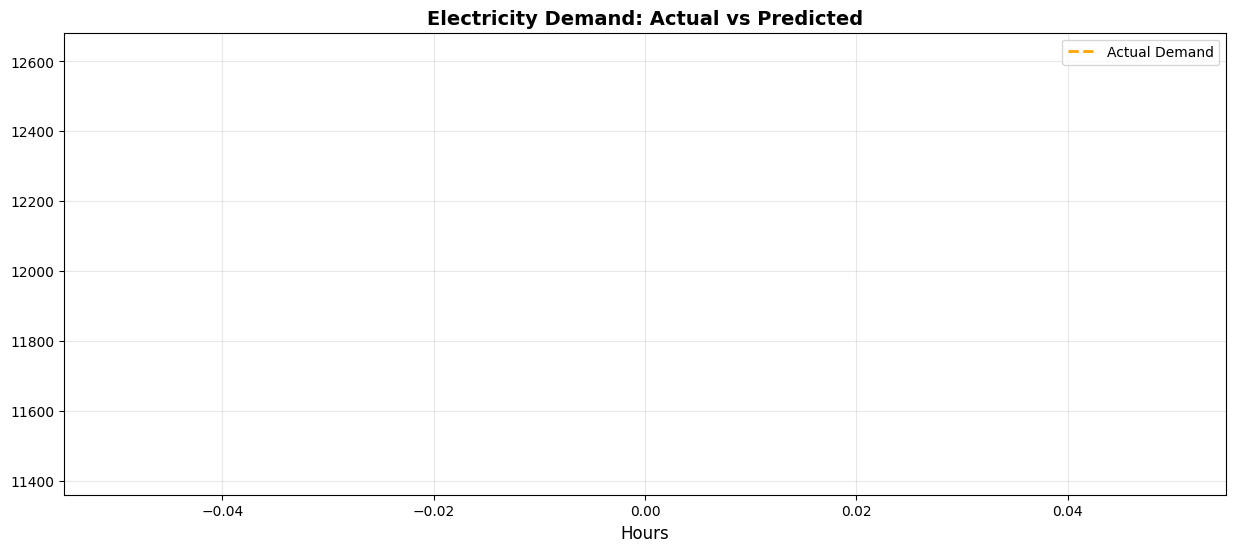

C:\Users\kavya\AppData\Local\Temp\ipykernel_39116\3176465426.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data= importance_df, palette='viridis')


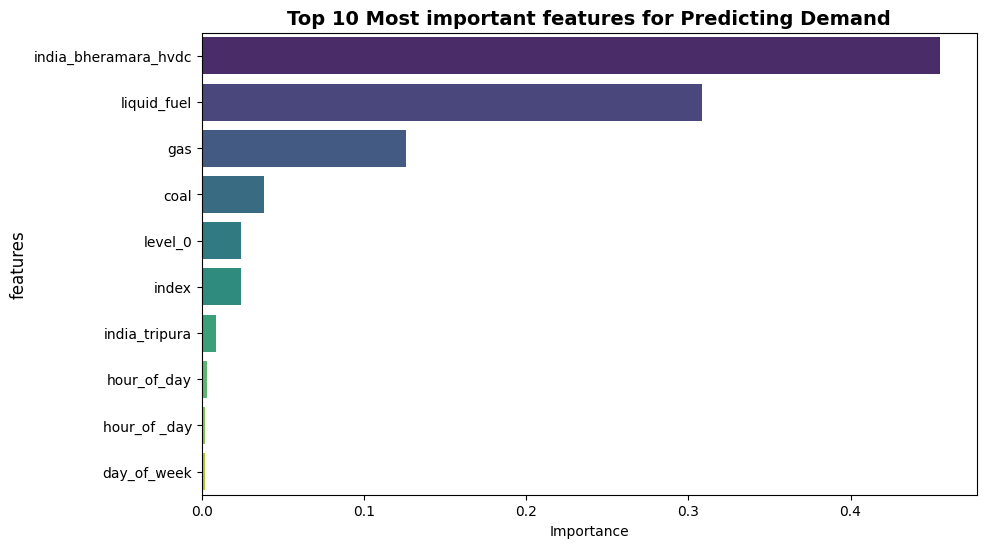

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== Data prep for model ===")
target_col ='demand_mw'

cols_to_drop =['datetime', 'demand_mw', 'generation_mw', 'load_shedding']

X = df_power[feature_cols]
y = df_power[target_col]

print(f"Features: Model in {len(feature_cols)} columns se pattern seekhega.")
print("\n=== Time-Series Train-Test Split ===")

split_point = int(len(df_power) * 0.8)
X_train_data = X.iloc[:split_point]
X_test_data = X.iloc[split_point:]
y_train_data = y.iloc[:split_point]
y_test_data = y.iloc[split_point:]

print(f"Training on: {len(X_train_data)} rows (Past Data)")
print(f"Testing on: {len(X_test_data)} rows (Future Data)")

print("\n=== Training the ML Model ===")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

print("Model is training ")
rf_model.fit(X_train_data, y_train_target)
print("Model training done")

print("n=== Making prediction ===")
predictions = rf_model.predict(X_test_data)

mae = mean_absolute_error(y_test_target, predictions)
rmse = np.sqrt(mean_squared_error(y_test_target, predictions))
r2 = r2_score(y_test_target, predictions) 

print(f"--> Mean Absolute Error (MAE): {mae:.2f} MW")
print(f"--> Root Mean Squared Error (RMSE): {rmse:.2f} MW")
print(f"--> R-squared Score: {r2:.4f}")

print("=== Visualization ===")
plt.figure(figsize=(15, 6))
plt.plot(y_test_target.values[-200], label='Actual Demand', color='orange', linestyle='dashed', linewidth=2)
plt.title('Electricity Demand: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Hours', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data= importance_df, palette='viridis')
plt.title('Top 10 Most important features for Predicting Demand', fontsize=14, fontweight='bold')
plt.ylabel('features', fontsize=12)
plt.show()